In [1]:
import src.tecan_func as tf
import importlib
import matplotlib.pyplot as plt
import os

importlib.reload(tf)
data_path = os.path.join(os.path.dirname(os.getcwd()),'reader_data','SDS_140925','ODcherrySDS_14_09_25.xlsx')
info_path = os.path.join(os.path.dirname(os.getcwd()),'reader_data','SDS_140925','plate_info.csv')
tecan_data = tf.tecan(path_to_data=data_path,path_to_info=info_path)
tecan_data.remove_background(fixed_background=0.087)
tecan_data.remove_spikes('OD_corrected')
time_ind = {'T0': 10084,'T1': 17961,'T2': 26561,'T3': 98138} #exp 140925
#time_ind = {'T0': 10427,'T1': 17645,'T2': 26498,'T3': 96198} #exp 020925
tecan_data.align_times('OD_corrected',time_ind)
tecan_data.get_derivative('OD_corrected_aligned',sigma=4)

C:\Users\owner\Documents\Projects\dysregulated-persistence\src\tecan_func.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(axis=0, how='all', inplace=True)
C:\Users\owner\Documents\Projects\dysregulated-persistence\src\tecan_func.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(axis=0, how='all', inplace=True)
C:\Users\owner\Documents\Projects\dysregulated-persistence\src\tecan_func.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retur

In [5]:
condition = 'ERM'
replicate = 'R1'
time='T1'
tecan_data.plot_condition('OD_corrected_aligned',[f'{condition}_T1_{replicate}',f'{condition}_T2_{replicate}', f'{condition}_T3_{replicate}'])
#tecan_data.plot_condition('OD_corrected_aligned',[f'{condition}_{time}_R1',f'{condition}_{time}_R2', f'{condition}_{time}_R3'])
#tecan_data.plot_condition('OD_corrected_aligned',['CTRL_T1_R1','CTRL_T2_R1', 'CTRL_T3_R1'])

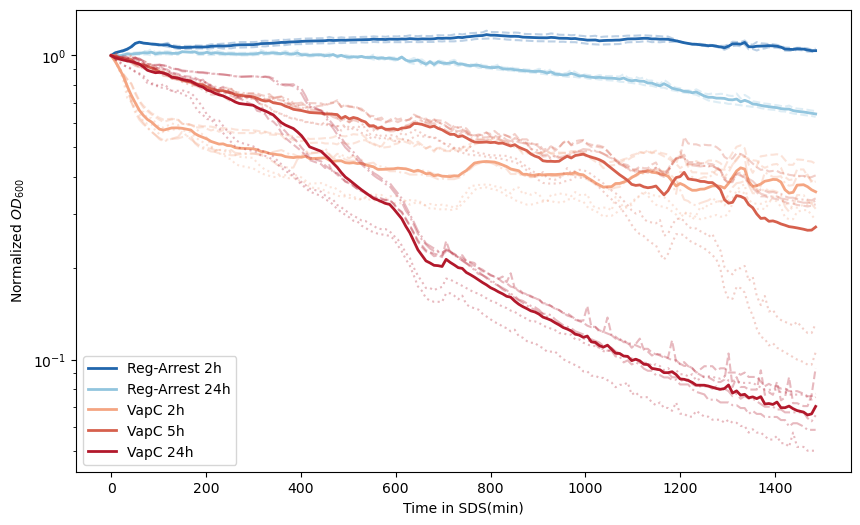

In [45]:
import numpy as np
import matplotlib.pyplot as plt
groups = {'Reg-Arrest 2h': ['CTRL_T1_R1'], 'Reg-Arrest 24h': ['CTRL_T3_R1'], 'VapC 2h': ['ERM_T1_R1','ERM_T1_R2','ERM_T1_R3'], 'VapC 5h': ['ERM_T2_R1','ERM_T2_R2','ERM_T2_R3'], 'VapC 24h': ['ERM_T3_R1','ERM_T3_R2','ERM_T3_R3']}
plot_colors = {'Reg-Arrest 2h': '#2166ac', 'Reg-Arrest 24h': '#92c5de', 'VapC 2h': '#f4a582', 'VapC 5h': '#d6604d', 'VapC 24h': '#b2182b'}
data = tecan_data.channels['OD_corrected_aligned']
line_styles = ['--','-.',':']
fig, ax = plt.subplots(figsize=(10,6))
for group, conditions in groups.items():
    group_mean = np.zeros(len(data))
    for i,condition in enumerate(conditions):
        wells = tecan_data.condition_locations(condition)
        ax.plot(data['Time [s]']/60, data[wells], alpha=0.3, color=plot_colors[group], ls = line_styles[i])
        group_mean += data[wells].mean(axis=1)
    group_mean /= len(conditions)
    ax.plot(data['Time [s]']/60, group_mean, label=group, color=plot_colors[group], linewidth=2, ls='-')
ax.set_yscale('log')
ax.set_xlabel('Time in SDS(min)')
ax.set_ylabel('Normalized $OD_{600}$')
ax.legend()

In [56]:
tecan_data.get_value('OD_corrected_aligned','ERM_T3_R3', 72000)

[0.06637167125542748, 0.08948863766007985]

0.23916568656776122
0.03835846894606282
0.5966060468175594
0.003738632292376632


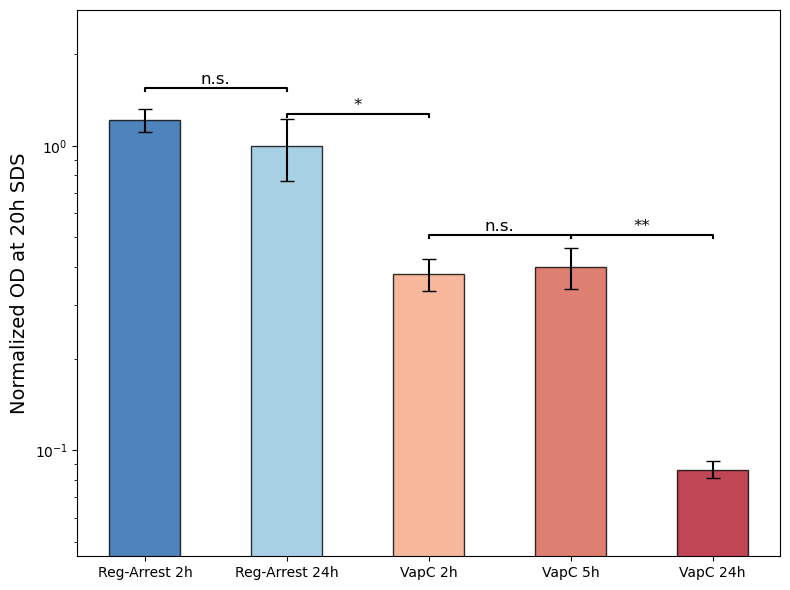

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

# --- load & build replicate-level means (pairing technical reps) ---
data_dir = os.path.join(os.path.dirname(os.getcwd()),'reader_data','SDS_140925')
data = pd.read_csv(os.path.join(data_dir,"normalizedOD_at_20h.csv"), header=0, index_col=0)

data_dict = {}        # will hold (group_mean, group_SE) for plotting
bio_means = {}        # stores list of biological-replicate means per group (for tests)

for col in data.columns:
    X = data[col].dropna().to_numpy()
    means = []
    errors = []
    for i in range(int(len(X)/2)):
        biorep = X[2*i:2*i+2]
        means.append(np.mean(biorep))
        errors.append(np.std(biorep, ddof=1)/np.sqrt(2))
    bio_means[col] = means[:]  # keep biological-replicate means

    # your original rule to choose SE (biological vs technical)
    if np.std(means, ddof=1) < np.mean(errors):
        data_dict[col] = (np.mean(means), np.mean(errors))
    else:
        data_dict[col] = (np.mean(means), np.std(means, ddof=1)/np.sqrt(len(means)))

# --- plotting ---
fig, ax = plt.subplots(figsize=(8,6))
labels = list(data_dict.keys())
plot_colors = ['#2166ac', '#92c5de','#f4a582', '#d6604d', '#b2182b']


bar_means = [data_dict[col][0] for col in labels]
bar_errs  = [data_dict[col][1] for col in labels]
bar_labels = ['Reg-Arrest 2h', 'Reg-Arrest 24h', 'VapC 2h', 'VapC 5h', 'VapC 24h']
bars = ax.bar(bar_labels, bar_means, yerr=bar_errs, capsize=5,
              color=plot_colors[:len(labels)], alpha=0.8, edgecolor='black', width=0.5)

ax.set_ylabel('Normalized OD at 20h SDS', fontsize=14)
ax.set_yscale('log')
ax.margins(y=0.2)  # add headroom for significance caps

# --- significance helpers ---
def get_pval(means, errors, n1, n2):
    tstat = (means[0] - means[1]) / np.sqrt(errors[0] ** 2  + errors[1] ** 2)
    df = n1 + n2 - 2
    return t.sf(tstat, df)


def p_to_stars(p):
    if np.isnan(p):   return 'n.s.'
    if p < 1e-4:      return '****'
    if p < 1e-3:      return '***'
    if p < 0.01:      return '**'
    if p < 0.05:      return '*'
    return 'n.s.'

def add_sig_between(ax, bar1, bar2, text, y_mult=1.15, cap_mult=1.02, text_mult=1.01):
    x1 = bar1.get_x() + bar1.get_width()/2
    x2 = bar2.get_x() + bar2.get_width()/2
    y_base = max(bar1.get_height(), bar2.get_height())
    y = y_base * y_mult
    y_cap = y * cap_mult
    ax.plot([x1, x1, x2, x2], [y, y_cap, y_cap, y], lw=1.5, c='black')
    ax.text((x1+x2)/2, y_cap * text_mult, text, ha='center', va='bottom', fontsize=12)

# --- compute Welch t-tests between neighbor bars and annotate ---
for i in range(len(labels)-1):
    g1, g2 = labels[i], labels[i+1]
    means = [data_dict[g1][0], data_dict[g2][0]]
    errors = [data_dict[g1][1], data_dict[g2][1]]

    # Welch t-test on biological-replicate means (needs n>=2 ideally)
    p = get_pval(means, errors, len(bio_means[g1]), len(bio_means[g2]))
    print(p)
    add_sig_between(ax, bars[i], bars[i+1], p_to_stars(p), y_mult=1.25)

plt.tight_layout()
plt.show()


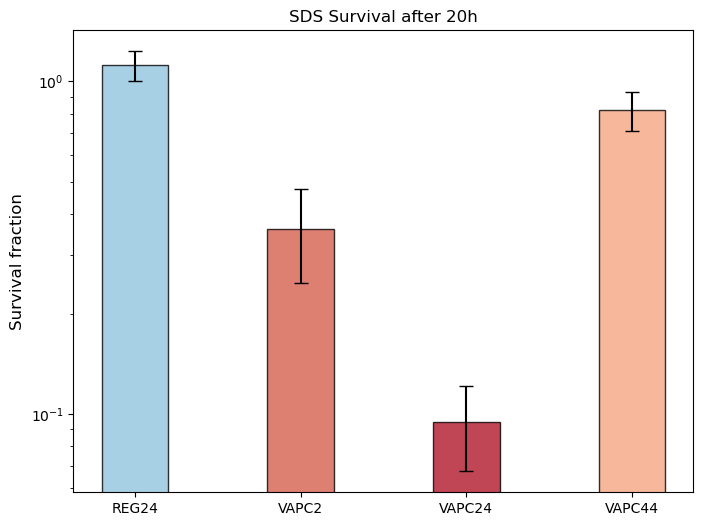

In [101]:
data_dir = os.path.join(os.path.dirname(os.getcwd()),'reader_data','SDS_140925')
data = pd.read_csv(os.path.join(data_dir,"SDS_survival.csv"), header=0, index_col=0)
# plot bars with error bars
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,6))
labels = data.columns.tolist()
values = data.iloc[0,:].tolist()
errors = data.iloc[1,:].tolist()
ind = [1,0,2,3]
values = [values[i] for i in ind]
errors = [errors[i] for i in ind]
labels = [labels[i] for i in ind]
plot_colors = [ '#92c5de','#d6604d', '#b2182b','#f4a582']
bars = ax.bar(labels, values, yerr=errors, capsize=5, color=plot_colors, alpha=0.8, edgecolor='black', width=0.4)
ax.set_title('SDS Survival after 20h', fontsize=12)
ax.set_ylabel('Survival fraction', fontsize=12)
ax.set_yscale('log')

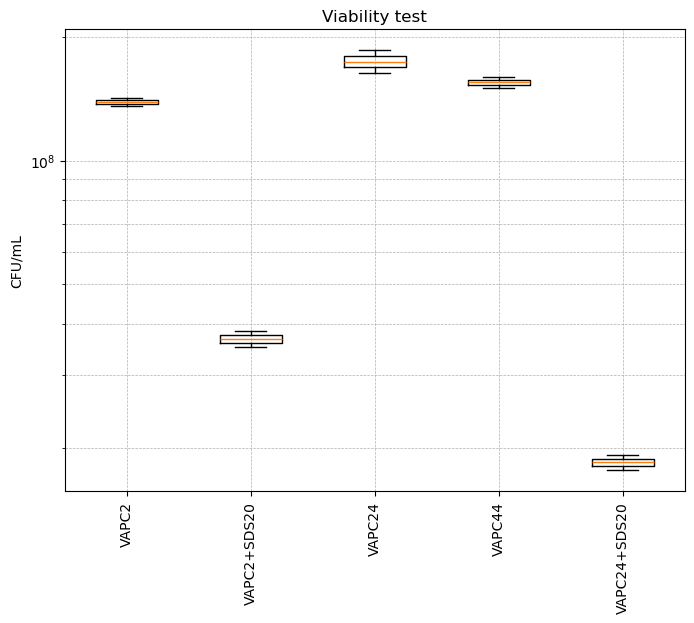

In [15]:
# get cfu data
import pandas as pd
import numpy as np
data_dir = os.path.join(os.path.dirname(os.getcwd()),'reader_data','SDS_140925')
data_path = os.path.join(data_dir,"CFUs.csv")
dilution_factor = 10*20**4
data = pd.read_csv(data_path, header=1)
data_dict = {}
for col in data.columns:
    if data[col].iloc[0] not in data_dict.keys() and 'VAPC' in str(data[col].iloc[0]):
        data_dict[data[col].iloc[0]]=data[col].iloc[1:].dropna().to_list()
# plot whisker plot
plt.figure(figsize=(8,6))
labels = list(data_dict.keys())
values = list([list(map(lambda x: float(x)*dilution_factor,val)) for val in data_dict.values()])
plt.boxplot(values, tick_labels=labels)
plt.yscale('log')
plt.ylabel('CFU/mL')
plt.title('Viability test')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(rotation=90)
#plt.ylim(1e8,1e9)
plt.show()